2026-05-25 19:16:45 - [INFO] - BẮT ĐẦU PIPELINE CHO MÃ GIAO DỊCH: BTC-USD
2026-05-25 19:16:45 - [INFO] - Đang lấy dữ liệu thời gian thực từ Yahoo Finance...
2026-05-25 19:16:46 - [INFO] - Thu thập thành công 2337 ngày giao dịch.
2026-05-25 19:16:46 - [INFO] - Đang đưa dữ liệu vào FinancialFeatureExtractor...
2026-05-25 19:16:46 - [INFO] - Đang phân luồng dữ liệu cho các nhóm (EDA, Model, Live)...
2026-05-25 19:16:46 - [INFO] - HOÀN TẤT XUẤT 3 TẬP DỮ LIỆU CHUYÊN BIỆT THÀNH CÔNG.
2026-05-25 19:16:46 - [INFO] - KÍCH HOẠT MODULE EDA NÂNG CAO: Đang chạy thống kê trực quan...


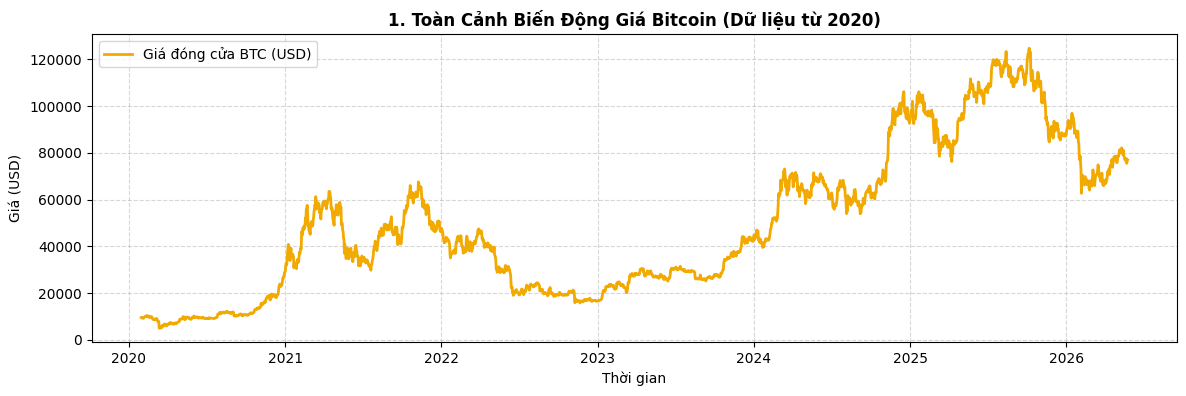

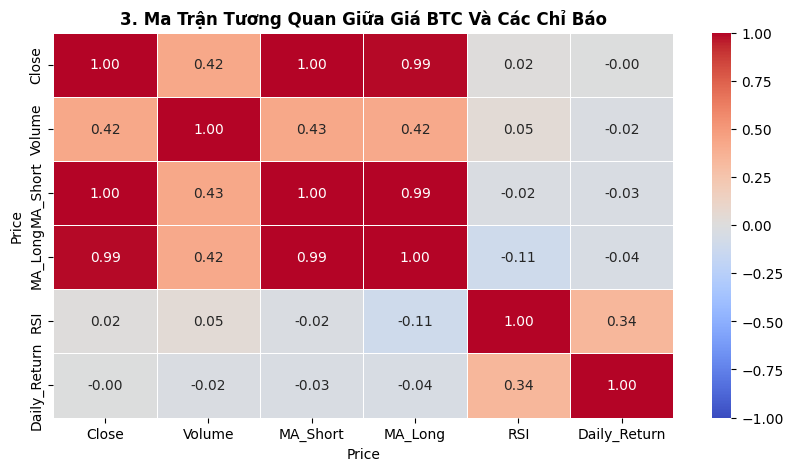


[TOÁN] KẾT QUẢ KIỂM ĐỊNH TÍNH DỪNG (ADF TEST)
 > Chuỗi giá gốc (Close)       -> ADF Stat: -1.3809 | p-value: 0.5914
 > Chuỗi sai phân (Daily Return)-> ADF Stat: -12.4460 | p-value: 0.0000


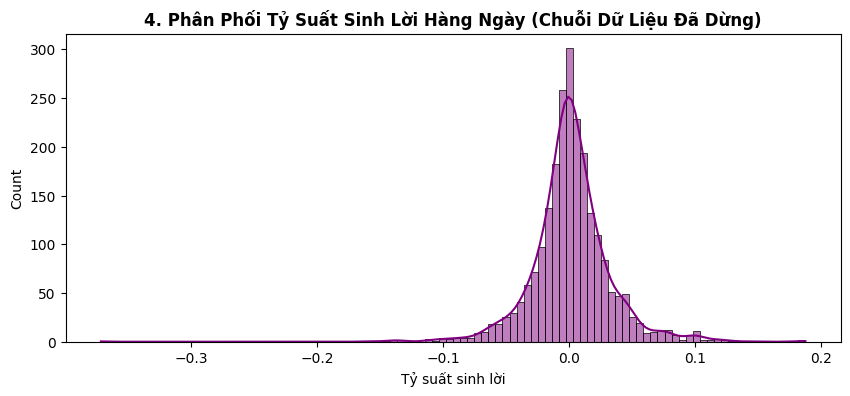


[TOÁN] PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA)
 > Thành phần PC1 giải thích được: 99.43% thông tin gốc.
 > Thành phần PC2 giải thích được: 0.38% thông tin gốc.
 => TỔNG CỘNG LƯỢNG THÔNG TIN GIỮ LẠI: 99.80%


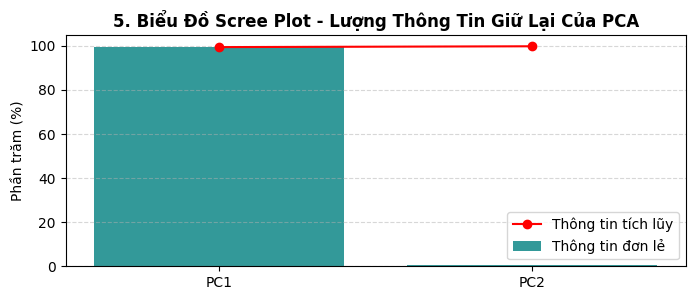

2026-05-25 19:16:47 - [INFO] - KÍCH HOẠT MODULE MACHINE LEARNING & DEEP LEARNING (GIAI ĐOẠN 4)...
2026-05-25 19:16:47 - [INFO] - Kích thước tập huấn luyện (Train): 1845 | Tập kiểm thử (Test): 462


2026-05-25 19:16:48 - [WARNING] - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
2026-05-25 19:16:48 - [INFO] - Đang huấn luyện mạng học sâu LSTM...


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


2026-05-25 19:16:53 - [INFO] - Đã đóng gói lưu trữ mô hình tối ưu nhất: Linear Regression



[KẾT QUẢ SO SÁNH HIỆU NĂNG GIAI ĐOẠN 4]
               Model           MAE          RMSE   R2 Score
0  Linear Regression   1494.137154   2070.948237   0.984581
1      Random Forest   6183.017456   8003.622939   0.769696
2               LSTM  90985.169052  92501.063876 -29.762443


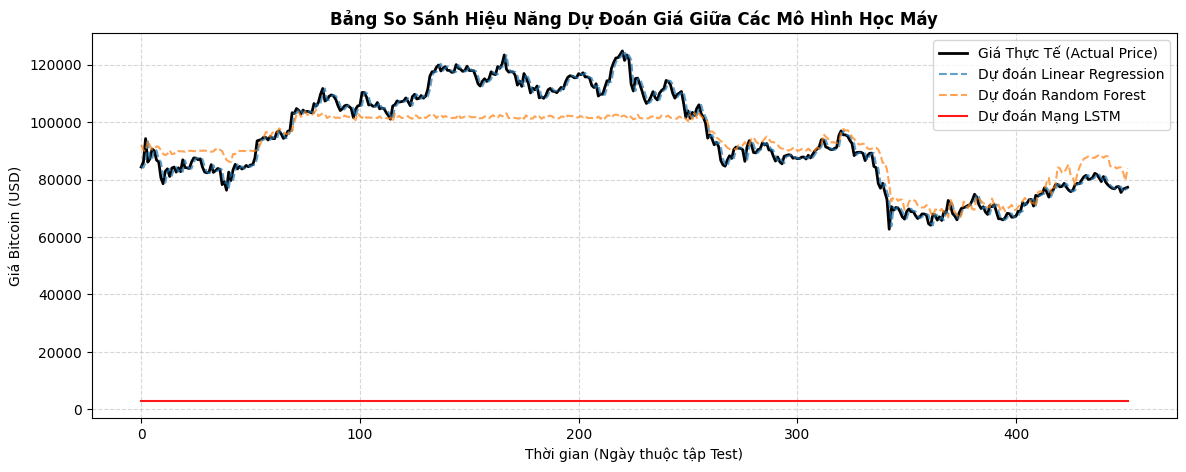


[TIẾN HÀNH DỰ BÁO GIÁ BITCOIN CHO NGÀY TIẾP THEO]
 > Đang kích hoạt bộ não dự báo: Linear Regression...
🚀 GIÁ BITCOIN DỰ ĐOÁN CHO NGÀY MAI CHÍNH XÁC THỜI GIAN THỰC: 77242.79 USD


[ĐANG CHẠY GIAI ĐOẠN 5: BACKTESTING]
Chỉ số lỗi mô hình được chọn (Linear Regression) -> MAE: 1486.87 USD | MAPE: 1.64%

[KẾT QUẢ ĐẦU TƯ TRÊN TẬP KIỂM THỬ THỰC TẾ]:
 > Lợi nhuận chiến lược Mua & Giữ truyền thống (Buy & Hold): -8.39%
 > Lợi nhuận chiến lược do Bot AI (Linear Regression) điều hành: -4.57%



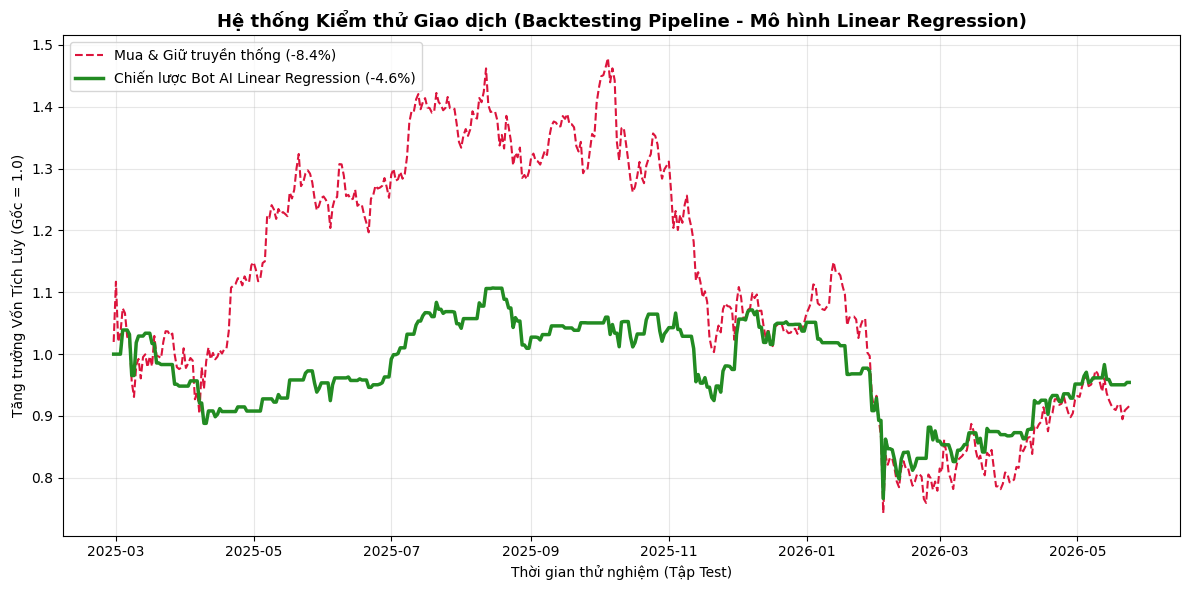

In [1]:
import logging
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

warnings.filterwarnings('ignore')

# ==========================================
# CẤU HÌNH HỆ THỐNG NHẬT KÝ (LOGGING)
# ==========================================
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - [%(levelname)s] - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

# ==========================================
# MODULE 1: BỘ TRÍCH XUẤT ĐẶC TRƯNG TÀI CHÍNH
# ==========================================
class FinancialFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, rsi_period=14, ma_short=7, ma_long=30):
        self.rsi_period = rsi_period
        self.ma_short = ma_short
        self.ma_long = ma_long

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = X.copy()
        
        # 1. Nhóm Trend (Xu hướng)
        df['MA_Short'] = df['Close'].rolling(window=self.ma_short).mean()
        df['MA_Long'] = df['Close'].rolling(window=self.ma_long).mean()
        
        # 2. Nhóm Momentum (Động lượng) - RSI
        delta = df['Close'].diff()
        gain = delta.where(delta > 0, 0.0).ewm(alpha=1/self.rsi_period, adjust=False).mean()
        loss = (-delta.where(delta < 0, 0.0)).ewm(alpha=1/self.rsi_period, adjust=False).mean()
        df['RSI'] = 100 - (100 / (1 + (gain / (loss + 1e-9))))
        
        # 3. Nhóm Volatility (Biến động) - Bollinger Bands
        bb_middle = df['Close'].rolling(window=20).mean()
        bb_std = df['Close'].rolling(window=20).std()
        df['BB_Upper'] = bb_middle + (2 * bb_std)
        df['BB_Lower'] = bb_middle - (2 * bb_std)
        
        # 4. Nhóm Time Dependency (Độ trễ)
        df['Daily_Return'] = df['Close'].pct_change()
        df['Lag_1_Close'] = df['Close'].shift(1)
        
        # 5. Khởi tạo Biến mục tiêu (Target = Giá đóng cửa ngày tiếp theo)
        df['Target_Next_Day_Price'] = df['Close'].shift(-1)
        
        return df

# ==========================================
# MODULE 2: BỘ PHÂN TÍCH TOÁN HỌC & TRỰC QUAN HÓA
# ==========================================
class AdvancedVisualizerEDA:
    @staticmethod
    def run_analysis(df_eda):
        logging.info("KÍCH HOẠT MODULE EDA NÂNG CAO: Đang chạy thống kê trực quan...")
        df_clean = df_eda.dropna()

        # ĐỒ THỊ 1: Toàn cảnh giá
        plt.figure(figsize=(14, 4))
        plt.plot(df_clean.index, df_clean['Close'], color='#f2a900', label='Giá đóng cửa BTC (USD)', linewidth=2)
        plt.title('1. Toàn Cảnh Biến Động Giá Bitcoin (Dữ liệu từ 2020)', fontsize=12, fontweight='bold')
        plt.xlabel('Thời gian')
        plt.ylabel('Giá (USD)')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.show()

        # ĐỒ THỊ 3: Ma trận tương quan Heatmap
        plt.figure(figsize=(10, 5))
        features_corr = ['Close', 'Volume', 'MA_Short', 'MA_Long', 'RSI', 'Daily_Return']
        corr_matrix = df_clean[features_corr].corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
        plt.title('3. Ma Trận Tương Quan Giữa Giá BTC Và Các Chỉ Báo', fontsize=12, fontweight='bold')
        plt.show()

        # TOÁN CHUYÊN SÂU 1: Kiểm định tính dừng (ADF Test)
        print("\n" + "="*50 + "\n[TOÁN] KẾT QUẢ KIỂM ĐỊNH TÍNH DỪNG (ADF TEST)\n" + "="*50)
        from statsmodels.tsa.stattools import adfuller
        adf_raw = adfuller(df_clean['Close'])
        print(f" > Chuỗi giá gốc (Close)       -> ADF Stat: {adf_raw[0]:.4f} | p-value: {adf_raw[1]:.4f}")
        adf_diff = adfuller(df_clean['Daily_Return'])
        print(f" > Chuỗi sai phân (Daily Return)-> ADF Stat: {adf_diff[0]:.4f} | p-value: {adf_diff[1]:.4f}")

        # ĐỒ THỊ 4: Vẽ biểu đồ phân phối Đuôi béo
        plt.figure(figsize=(10, 4))
        sns.histplot(df_clean['Daily_Return'], kde=True, color='purple', bins=100)
        plt.title('4. Phân Phối Tỷ Suất Sinh Lời Hàng Ngày (Chuỗi Dữ Liệu Đã Dừng)', fontsize=12, fontweight='bold')
        plt.xlabel('Tỷ suất sinh lời')
        plt.show()

        # TOÁN CHUYÊN SÂU 2: Phân tích thành phần chính (PCA)
        print("\n" + "="*50 + "\n[TOÁN] PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA)\n" + "="*50)
        pca_features = ['MA_Short', 'MA_Long', 'BB_Upper', 'BB_Lower']
        X_indicators = df_clean[pca_features]
        X_scaled = StandardScaler().fit_transform(X_indicators)
        
        pca = PCA(n_components=2)
        pca.fit(X_scaled)
        variance_ratio = pca.explained_variance_ratio_
        for i, ratio in enumerate(variance_ratio):
            print(f" > Thành phần PC{i+1} giải thích được: {ratio*100:.2f}% thông tin gốc.")
        print(f" => TỔNG CỘNG LƯỢNG THÔNG TIN GIỮ LẠI: {np.sum(variance_ratio)*100:.2f}%")

        # ĐỒ THỊ 5: Biểu đồ Scree Plot
        plt.figure(figsize=(8, 3))
        plt.bar([f'PC{i+1}' for i in range(2)], variance_ratio*100, color='teal', alpha=0.8, label='Thông tin đơn lẻ')
        plt.plot([f'PC{i+1}' for i in range(2)], np.cumsum(variance_ratio)*100, color='red', marker='o', label='Thông tin tích lũy')
        plt.title('5. Biểu Đồ Scree Plot - Lượng Thông Tin Giữ Lại Của PCA', fontsize=12, fontweight='bold')
        plt.ylabel('Phần trăm (%)')
        plt.legend()
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.show()

# ==========================================
# MODULE 4: HỆ THỐNG HUẤN LUYỆN & AI PREDICTION
# ==========================================
class CryptoModelTrainer:
    @staticmethod
    def train_and_evaluate(df_featured):
        logging.info("KÍCH HOẠT MODULE MACHINE LEARNING & DEEP LEARNING (GIAI ĐOẠN 4)...")
        
        features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_Short', 'MA_Long', 'RSI', 'Daily_Return', 'Lag_1_Close']
        target = 'Target_Next_Day_Price'

        df_features_only = df_featured[features].dropna()
        latest_10_days_live = df_features_only.tail(10)

        df_clean = df_featured.dropna()
        X = df_clean[features]
        y = df_clean[target]

        split_index = int(len(df_clean) * 0.8)
        X_train, X_test = X[:split_index], X[split_index:]
        y_train, y_test = y[:split_index], y[split_index:]

        logging.info(f"Kích thước tập huấn luyện (Train): {len(X_train)} | Tập kiểm thử (Test): {len(X_test)}")

        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        joblib.dump(scaler, 'scaler.pkl')

        # 1. LINEAR REGRESSION
        lr_model = LinearRegression()
        lr_model.fit(X_train_scaled, y_train)
        y_pred_lr = lr_model.predict(X_test_scaled)
        mae_lr = mean_absolute_error(y_test, y_pred_lr)

        # 2. RANDOM FOREST
        rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
        rf_model.fit(X_train_scaled, y_train)
        y_pred_rf = rf_model.predict(X_test_scaled)
        mae_rf = mean_absolute_error(y_test, y_pred_rf)

        # 3. NETWORK LSTM (Sliding Window Đầu vào Chuỗi thời gian)
        def create_lstm_dataset(X_data, y_data, lookback=10):
            X_lstm, y_lstm = [], []
            for i in range(len(X_data) - lookback):
                X_lstm.append(X_data[i:(i + lookback)])
                y_lstm.append(y_data.iloc[i + lookback])
            return np.array(X_lstm), np.array(y_lstm)

        LOOKBACK = 10
        X_train_lstm, y_train_lstm = create_lstm_dataset(X_train_scaled, y_train, LOOKBACK)
        X_test_lstm, y_test_lstm = create_lstm_dataset(X_test_scaled, y_test, LOOKBACK)

        lstm_model = Sequential([
            LSTM(64, return_sequences=False, input_shape=(LOOKBACK, X_train_scaled.shape[1])),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        lstm_model.compile(optimizer='adam', loss='mean_squared_error')
        
        logging.info("Đang huấn luyện mạng học sâu LSTM...")
        lstm_model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, validation_split=0.1, verbose=0)
        y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

        # Đồng bộ hóa kích thước đánh giá (Cắt bỏ LOOKBACK ngày đầu)
        y_test_adjusted = y_test.iloc[LOOKBACK:]
        mae_lstm = mean_absolute_error(y_test_adjusted, y_pred_lstm)
        rmse_lstm = np.sqrt(mean_squared_error(y_test_adjusted, y_pred_lstm))
        r2_lstm = r2_score(y_test_adjusted, y_pred_lstm)

        y_pred_lr_adj = y_pred_lr[LOOKBACK:]
        y_pred_rf_adj = y_pred_rf[LOOKBACK:]

        results = pd.DataFrame({
            'Model': ['Linear Regression', 'Random Forest', 'LSTM'],
            'MAE': [mae_lr, mae_rf, mae_lstm],
            'RMSE': [
                np.sqrt(mean_squared_error(y_test_adjusted, y_pred_lr_adj)),
                np.sqrt(mean_squared_error(y_test_adjusted, y_pred_rf_adj)),
                rmse_lstm
            ],
            'R2 Score': [
                r2_score(y_test_adjusted, y_pred_lr_adj),
                r2_score(y_test_adjusted, y_pred_rf_adj),
                r2_lstm
            ]
        })

        print("\n" + "="*50 + "\n[KẾT QUẢ SO SÁNH HIỆU NĂNG GIAI ĐOẠN 4]\n" + "="*50)
        print(results)

        # Tự động lưu mô hình có sai số RMSE thấp nhất
        best_model_name = results.loc[results['RMSE'].idxmin()]['Model']
        if best_model_name == 'Linear Regression':
            joblib.dump(lr_model, 'best_bitcoin_model.pkl')
            final_pred_signals = y_pred_lr_adj
        elif best_model_name == 'Random Forest':
            joblib.dump(rf_model, 'best_bitcoin_model.pkl')
            final_pred_signals = y_pred_rf_adj
        else:
            lstm_model.save('best_bitcoin_model_lstm.h5')
            final_pred_signals = y_pred_lstm
        logging.info(f"Đã đóng gói lưu trữ mô hình tối ưu nhất: {best_model_name}")

        # Vẽ đồ thị tổng hợp kết quả dự báo của 3 mô hình
        plt.figure(figsize=(14, 5))
        plt.plot(y_test_adjusted.values, label='Giá Thực Tế (Actual Price)', color='black', linewidth=2)
        plt.plot(y_pred_lr_adj, label='Dự đoán Linear Regression', linestyle='--', alpha=0.7)
        plt.plot(y_pred_rf_adj, label='Dự đoán Random Forest', linestyle='--', alpha=0.7)
        plt.plot(y_pred_lstm, label='Dự đoán Mạng LSTM', linestyle='-', alpha=0.9, color='red')
        plt.title('Bảng So Sánh Hiệu Năng Dự Đoán Giá Giữa Các Mô Hình Học Máy', fontsize=12, fontweight='bold')
        plt.xlabel('Thời gian (Ngày thuộc tập Test)')
        plt.ylabel('Giá Bitcoin (USD)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

        # TIẾN HÀNH DỰ BÁO ĐỘNG CHO NGÀY MAI
        print("\n" + "="*50 + "\n[TIẾN HÀNH DỰ BÁO GIÁ BITCOIN CHO NGÀY TIẾP THEO]\n" + "="*50)
        latest_10_days_scaled = scaler.transform(latest_10_days_live)
        print(f" > Đang kích hoạt bộ não dự báo: {best_model_name}...")

        if best_model_name == 'Linear Regression':
            next_day_prediction = lr_model.predict(latest_10_days_scaled[-1].reshape(1, -1))[0]
        elif best_model_name == 'Random Forest':
            next_day_prediction = rf_model.predict(latest_10_days_scaled[-1].reshape(1, -1))[0]
        else:
            latest_data_lstm = latest_10_days_scaled.reshape(1, LOOKBACK, latest_10_days_scaled.shape[1])
            pred_lstm = lstm_model.predict(latest_data_lstm)
            next_day_prediction = pred_lstm.flatten()[0]

        print(f"🚀 GIÁ BITCOIN DỰ ĐOÁN CHO NGÀY MAI CHÍNH XÁC THỜI GIAN THỰC: {next_day_prediction:.2f} USD")
        print("="*50 + "\n")

        # Trả về các dữ liệu cần thiết để chuyển giao sang Module Backtest
        return y_test_adjusted, final_pred_signals, best_model_name

# =====================================================================
# GIAI ĐOẠN 5: CHIẾN LƯỢC ĐẦU TƯ THỰC TẾ TRÊN MÔ HÌNH (BACKTESTING)
# =====================================================================
class CryptoBacktester:
    @staticmethod
    def run_backtest(y_test_adjusted, predicted_close, best_model_name):
        print("\n" + "="*50 + "\n[ĐANG CHẠY GIAI ĐOẠN 5: BACKTESTING]\n" + "="*50)
        
        # Đồng bộ hóa dữ liệu kiểm thử thực tế và dữ liệu AI dự đoán
        df_bt = pd.DataFrame(index=y_test_adjusted.index)
        df_bt['Actual_Close'] = y_test_adjusted.values
        df_bt['AI_Predicted_Next_Day'] = predicted_close

        # 1. Đánh giá sai số toán học cơ bản
        mae = mean_absolute_error(df_bt['Actual_Close'], df_bt['AI_Predicted_Next_Day'])
        mape = np.mean(np.abs((df_bt['Actual_Close'] - df_bt['AI_Predicted_Next_Day']) / df_bt['Actual_Close'])) * 100
        print(f"Chỉ số lỗi mô hình được chọn ({best_model_name}) -> MAE: {mae:.2f} USD | MAPE: {mape:.2f}%")

        # 2. Xây dựng chiến lược giả lập bằng Vectorization toán học song phẳng chuẩn xác
        df_bt['Actual_Return'] = df_bt['Actual_Close'].pct_change()

        # Phát tín hiệu: Nếu AI đoán ngày mai (AI_Predicted_Next_Day) > Thực tế hôm nay (Actual_Close) -> MUA (1)
        # Sử dụng .shift(1) trên Actual_Close để so khớp đồng thời đúng mốc dòng thời gian
        df_bt['Trading_Signal'] = np.where(df_bt['AI_Predicted_Next_Day'] > df_bt['Actual_Close'].shift(1), 1, 0)
        
        # Shift tín hiệu lùi 1 ngày để chống rò rỉ thông tin trước (Chống Look-ahead bias)
        df_bt['Strategy_Return'] = df_bt['Trading_Signal'].shift(1) * df_bt['Actual_Return']
        df_bt.dropna(inplace=True)

        # Tính tổng vốn tích lũy cấp số nhân (Bắt đầu từ gốc vốn bằng 1.0)
        df_bt['Buy_Hold_Capital'] = (1 + df_bt['Actual_Return']).cumprod()
        df_bt['AI_Strategy_Capital'] = (1 + df_bt['Strategy_Return']).cumprod()

        final_bh = (df_bt['Buy_Hold_Capital'].iloc[-1] - 1) * 100
        final_ai = (df_bt['AI_Strategy_Capital'].iloc[-1] - 1) * 100

        print(f"\n[KẾT QUẢ ĐẦU TƯ TRÊN TẬP KIỂM THỬ THỰC TẾ]:")
        print(f" > Lợi nhuận chiến lược Mua & Giữ truyền thống (Buy & Hold): {final_bh:.2f}%")
        print(f" > Lợi nhuận chiến lược do Bot AI ({best_model_name}) điều hành: {final_ai:.2f}%")
        print("="*50 + "\n")

        # 3. Trực quan đồ thị so sánh hiệu năng tăng trưởng tài sản
        plt.figure(figsize=(12, 6))
        plt.plot(df_bt.index, df_bt['Buy_Hold_Capital'], label=f'Mua & Giữ truyền thống ({final_bh:.1f}%)', color='crimson', linestyle='--')
        plt.plot(df_bt.index, df_bt['AI_Strategy_Capital'], label=f'Chiến lược Bot AI {best_model_name} ({final_ai:.1f}%)', color='forestgreen', linewidth=2.5)

        plt.title(f'Hệ thống Kiểm thử Giao dịch (Backtesting Pipeline - Mô hình {best_model_name})', fontsize=13, fontweight='bold')
        plt.xlabel('Thời gian thử nghiệm (Tập Test)')
        plt.ylabel('Tăng trưởng Vốn Tích Lũy (Gốc = 1.0)')
        plt.legend(loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# ==========================================
# MODULE 3: HỆ THỐNG ĐIỀU PHỐI PIPELINE TOÀN DIỆN
# ==========================================
class CryptoDataPipeline:
    def __init__(self, ticker="BTC-USD", start_date="2020-01-01", end_date=None):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date
        self.raw_data = None
        self.featured_data = None

    def execute_pipeline(self):
        logging.info(f"BẮT ĐẦU PIPELINE CHO MÃ GIAO DỊCH: {self.ticker}")
        
        # Bước 1: Fetch Data từ Yahoo Finance
        logging.info("Đang lấy dữ liệu thời gian thực từ Yahoo Finance...")
        df_raw = yf.download(tickers=self.ticker, start=self.start_date, end=self.end_date, progress=False)
        if isinstance(df_raw.columns, pd.MultiIndex):
            df_raw.columns = df_raw.columns.droplevel(1)
        self.raw_data = df_raw.sort_index(ascending=True)
        logging.info(f"Thu thập thành công {len(self.raw_data)} ngày giao dịch.")
        
        # Bước 2: Feature Engineering qua Scikit-Learn Transformer
        logging.info("Đang đưa dữ liệu vào FinancialFeatureExtractor...")
        extractor = FinancialFeatureExtractor(rsi_period=14, ma_short=7, ma_long=30)
        self.featured_data = extractor.transform(self.raw_data)
        
        # Bước 3: Đóng gói và Phân luồng dữ liệu xuất ra file cứng CSV
        self._export_datasets()
        
        # Bước 4: Kích hoạt module phân tích toán nâng cao EDA
        AdvancedVisualizerEDA.run_analysis(self.featured_data)

        # Bước 5: Kích hoạt luồng Máy học AI (Giai đoạn 4)
        y_test_adjusted, final_pred_signals, best_model_name = CryptoModelTrainer.train_and_evaluate(self.featured_data)
        
        # Bước 6: Kích hoạt hệ thống Kiểm thử mô phỏng dòng vốn đầu tư (Giai đoạn 5)
        CryptoBacktester.run_backtest(y_test_adjusted, final_pred_signals, best_model_name)

    def _export_datasets(self):
        logging.info("Đang phân luồng dữ liệu cho các nhóm (EDA, Model, Live)...")
        df = self.featured_data.copy()
        
        df_eda = df.drop(columns=['Target_Next_Day_Price'], errors='ignore')
        df_eda.to_csv("1_BTC_Data_EDA.csv")
        
        df_model = df.dropna(subset=['Target_Next_Day_Price']).dropna()
        df_model.to_csv("2_BTC_Data_Model.csv")
        
        df_live = df[df['Target_Next_Day_Price'].isna()].drop(columns=['Target_Next_Day_Price'])
        df_live.to_csv("3_BTC_Data_Live_Prediction.csv")
        
        logging.info("HOÀN TẤT XUẤT 3 TẬP DỮ LIỆU CHUYÊN BIỆT THÀNH CÔNG.")

# ==========================================
# THỰC THI CHƯƠNG TRÌNH TỰ ĐỘNG TOÀN DIỆN
# ==========================================
if __name__ == "__main__":
    pipeline = CryptoDataPipeline(ticker="BTC-USD", start_date="2020-01-01")
    pipeline.execute_pipeline()